# Exercise 1

Deadline 6.11.2025

## 1. Two dimensional data

In [1]:
from sklearn.datasets import make_moons
import numpy as np
import matplotlib.pyplot as plt

from numpy import exp, sqrt, pi

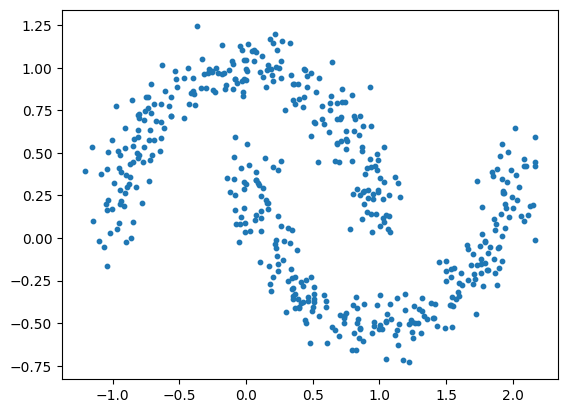

In [2]:
# Plot
X, y = make_moons(n_samples = 500, noise = 0.1, random_state = 42)
plt.scatter(X[:, 0], X[:, 1], s=10)

# Implement a class for each of the following models, including
# methods for fit(), sample(), and score_samples()

Next, we will implement classes, à la sklearn, providing methods for fit(), sample() and score_samples() without using the pre-defined classes, but formulating them independently.

We will create a class for each of the following models:

1. two-dimensional histogram
2. single Gaussian
3. Gaussian mixture model
4. kernel density estimator with a Gaussian kernel

For evaluation, we will implement the maximum mean discrepancy metric with squared exponential and inverse multi-quadratic kernels

$$ \mathrm{se}(x, x') = \mathrm{exp}(-\dfrac{||{x-x'}||^2}{h^2})$$

$$ \mathrm{imq}(x, x') = \dfrac{1}{\sqrt{1 + \dfrac{||{x-x'}||^2}{h^2}}}$$

### 1.1 Two dimensional histogram

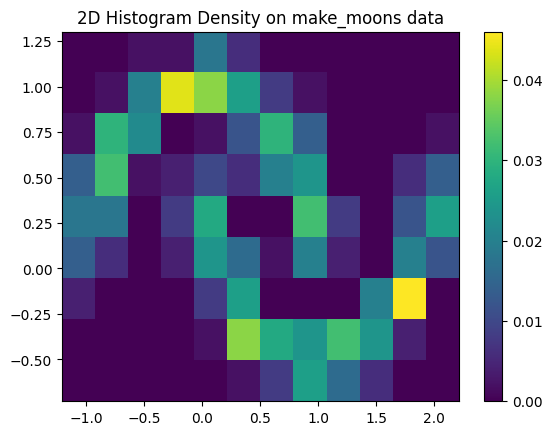

(12, 9)


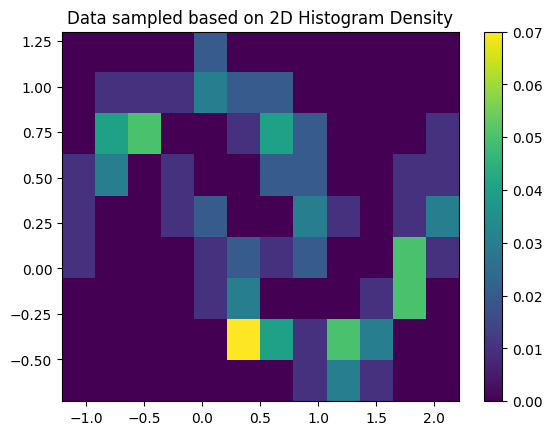

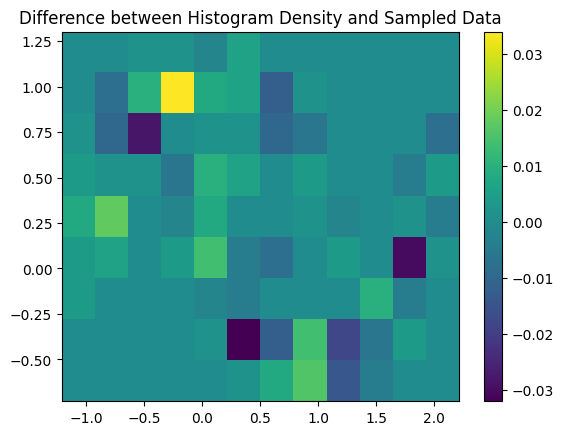

Score (se):  0.05759036497568273
Score (imq): 0.5093562138567052


In [3]:

class two_dim_histogram:
    def __init__(self):
        self.densities = None
        self.bin_edges_1 = None
        self.bin_edges_2 = None
        self.samples = None
        self.score = None
    # Method to fit 2d histogram
    '''
    As in 1d, need to determine p_k and bin sizes.
    
    In 1d, determined the bin sizes with the interquantile range IQR

        h_1D = 2 IQR / (N)^(1/3)

    In 2d, do the same in both dimensions
    '''
    def fit(self, X, y): # training_data := X, classes := y
        # Get n_samples
        n_samples = X.shape[0]

        # Determine Interquantile range
        # IQR = x_[3N/4] - x_[N/4]
        IQR_x1 = np.percentile(X[:, 0], 75) - np.percentile(X[:, 0], 25)
        IQR_x2 = np.percentile(X[:, 1], 75) - np.percentile(X[:, 1], 25)

        # Bin widths
        h_1 = 2 * IQR_x1 / ((n_samples) ** (1/3))
        h_2 = 2 * IQR_x2 / ((n_samples) ** (1/3))

        # Create bins k
        x1_min, x1_max = np.min(X[:, 0]), np.max(X[:, 0])
        x2_min, x2_max = np.min(X[:, 1]), np.max(X[:, 1])
        self.bin_edges_1 = np.arange(x1_min, x1_max + h_1, h_1)
        self.bin_edges_2 = np.arange(x2_min, x2_max + h_2, h_2)

        # Determine counts in bins k
        counts, _, _ = np.histogram2d(X[:, 0], X[:, 1], bins = [self.bin_edges_1, self.bin_edges_2])
        self.densities = counts / counts.sum()

        return self.densities, self.bin_edges_1, self.bin_edges_2

    # Method to sample
    def sample(self, n_samples):
        # First select bins based on densities
        '''
        This creates an array n_samples large where every entry marks the bin number
        from which we should sample
        '''
        bin_indices = np.random.choice(self.densities.size, 
            size = n_samples, 
            p = self.densities.flatten()) # flatten because only takes 1d array or int

        # Count instances of selected bins
        samples = np.bincount(bin_indices, 
                              minlength = self.densities.size
                              ).reshape(self.densities.shape)
        self.samples = samples / samples.sum()

        return self.samples

    # Method to score samples
    def score_samples(self, h = 1, metric = "squared_exponential"):
        
        if metric == "squared_exponential":
            self.score = self.squared_exponential(self.densities, self.samples, h)
        elif metric == "inverse_multi_quadratic":
            self.score = self.inverse_multi_quadratic(self.densities, self.samples, h)
        else:
            raise ValueError("Please select one of the metrics 'squared_exponential' or 'inverse_multi_quadratic'")

        return self.score
    
    def squared_exponential(self, x, x_prime, h):
        return exp(- ((np.linalg.norm(x - x_prime)) ** 2) / (h ** 2))
    
    def inverse_multi_quadratic(self, x, x_prime, h):
        return 1 / sqrt(1 + (np.linalg.norm(x - x_prime) ** 2) / (h ** 2))

# Fit 2d histogram model
model = two_dim_histogram()
make_moons_histogram2d, edges_1, edges_2 = model.fit(X, y)

# Plot 2d histogram density
plt.figure()
plt.title("2D Histogram Density on make_moons data")
plt.imshow(make_moons_histogram2d.T, 
           extent=[edges_1[0], edges_1[-1], edges_2[0], edges_2[-1]], 
           origin='lower', 
           cmap='viridis', 
           aspect='auto')
plt.colorbar()
plt.show()

# Sample from histogram
samples = model.sample(100)
print(samples.shape)
plt.figure()
plt.title("Data sampled based on 2D Histogram Density")
plt.imshow(samples.T, 
           extent=[edges_1[0], edges_1[-1], edges_2[0], edges_2[-1]], 
           origin='lower', 
           cmap='viridis', 
           aspect='auto')
plt.colorbar()
plt.show()

# Comparison between Histogram Density and Sampled data
plt.figure()
plt.title("Difference between Histogram Density and Sampled Data")
plt.imshow(make_moons_histogram2d.T - samples.T, 
           extent=[edges_1[0], edges_1[-1], edges_2[0], edges_2[-1]], 
           origin='lower', 
           cmap='viridis', 
           aspect='auto')
plt.colorbar()
plt.show()

# Score
score_se = model.score_samples(h = 0.05, metric = "squared_exponential")
score_imq = model.score_samples(h = 0.05, metric = "inverse_multi_quadratic")

print(f"Score (se):  {score_se}")
print(f"Score (imq): {score_imq}")

### 1.2 Single Gaussian

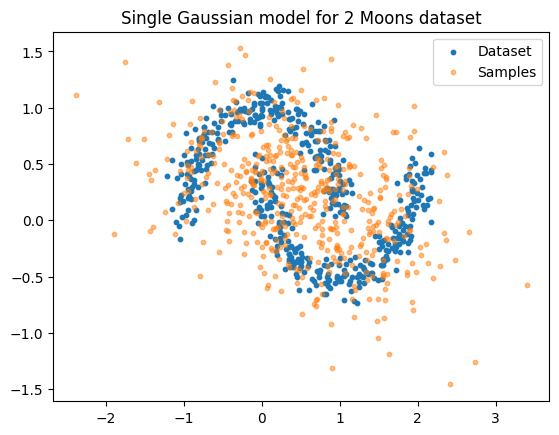

Score (se):  0.0
Score (imq): 0.0015408479450546857


In [11]:
from numpy.random import multivariate_normal

class single_gaussian:
    def __init__(self):
        self.densities = None
        self.mu = None
        self.Sigma = None
        self.samples = None
        self.score = None
    # Method to fit a single Gaussian
    '''
    Need to determine appropriate mu, sigma for a single Gaussian on top of the data
    '''
    def fit(self, X): # training_data := X
        # Gaussian with simply mu = np.mean, Sigma = np.cov
        self.mu = np.mean(X, axis = 0)
        self.Sigma = np.cov(X, rowvar = False)

        return self.mu, self.Sigma
    
    def sample(self, n_samples):
        self.samples = np.random.multivariate_normal(self.mu, self.Sigma, n_samples)
        return self.samples

    # Method to score samples
    def score_samples(self, h = 1, metric = "squared_exponential"):
        
        if metric == "squared_exponential":
            self.score = self.squared_exponential(X, self.samples, h)
        elif metric == "inverse_multi_quadratic":
            self.score = self.inverse_multi_quadratic(X, self.samples, h)
        else:
            raise ValueError("Please select one of the metrics 'squared_exponential' or 'inverse_multi_quadratic'")

        return self.score
    
    def squared_exponential(self, x, x_prime, h):
        return exp(- ((np.linalg.norm(x - x_prime)) ** 2) / (h ** 2))
    
    def inverse_multi_quadratic(self, x, x_prime, h):
        return 1 / sqrt(1 + (np.linalg.norm(x - x_prime) ** 2) / (h ** 2))

# Fit 2d single Gaussian model
model = single_gaussian()
make_moons_single_gaussian = model.fit(X)

# Sample from Gaussian
samples = model.sample(n_samples = X.shape[0])
plt.figure()
plt.title("Single Gaussian model for 2 Moons dataset")
plt.scatter(X[:, 0], X[:, 1], s=10, 
            label = "Dataset")
plt.scatter(samples[:, 0], samples[:, 1],
            alpha = 0.5, 
            s = 10,
            label = "Samples")
plt.legend()
plt.show()

# Score
score_se = model.score_samples(h = 0.05, metric = "squared_exponential")
score_imq = model.score_samples(h = 0.05, metric = "inverse_multi_quadratic")

print(f"Score (se):  {score_se}")
print(f"Score (imq): {score_imq}")



/var/folders/dr/34chm7gn07vdb_w184vptt640000gn/T/ipykernel_69909/57955110.py:21: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(x, y, z, levels=5, colors=color, alpha=0.5, label=label)


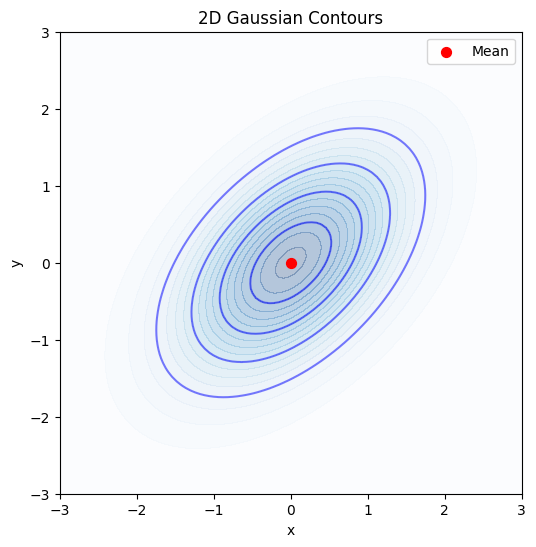